# Importing Libraries

In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import pickle

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression

# Model evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

#Data Sampling
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample


# EDA 1

In [ ]:
df = pd.read_csv("/content/creditcard.csv")
df.columns
df["Class"].value_counts()
df.shape
for i in df.columns:
  print(df[i].value_counts()) #Reveals last class imbalance
  print(df[i].isna().sum())
  print()
print(df.info())

0

0

0

0

0

0

0

0

0

0

0

0

0

0

0

0

0

0

0

0

0

0

0

0

0

0

0

0

0

0

0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float6

# EDA 2

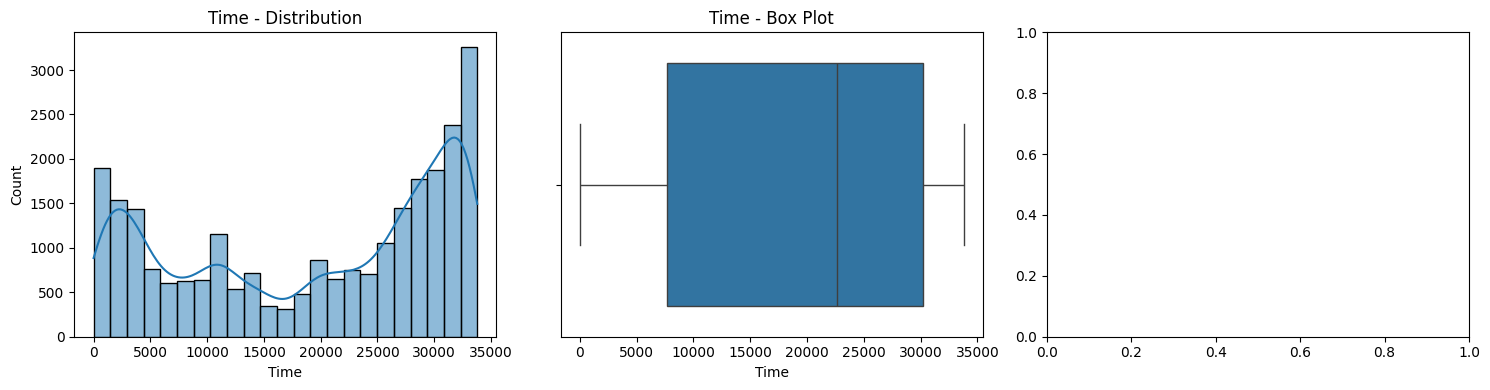

Time:
  Skewness: -0.344
  Kurtosis: -1.442


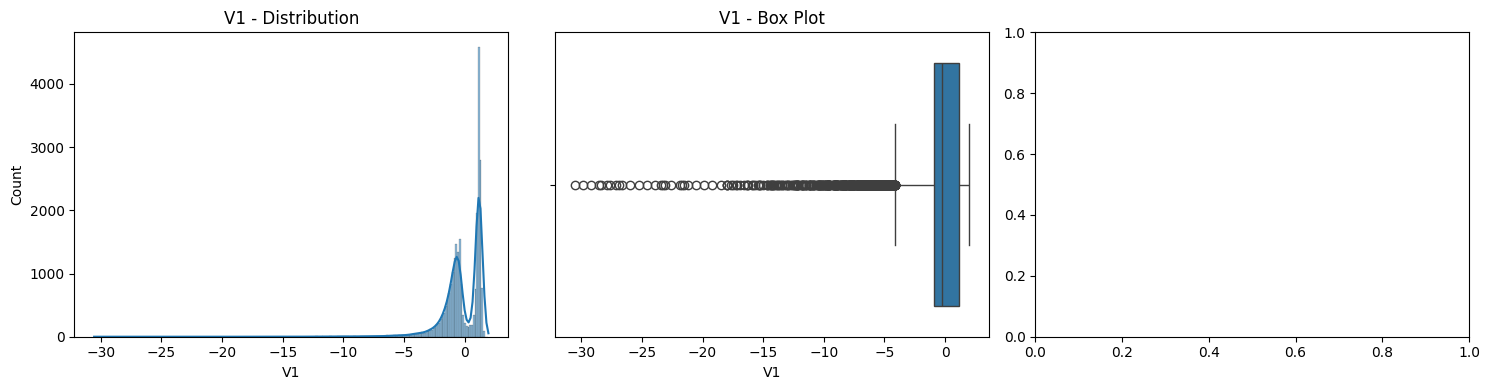

V1:
  Skewness: -4.320
  Kurtosis: 40.584


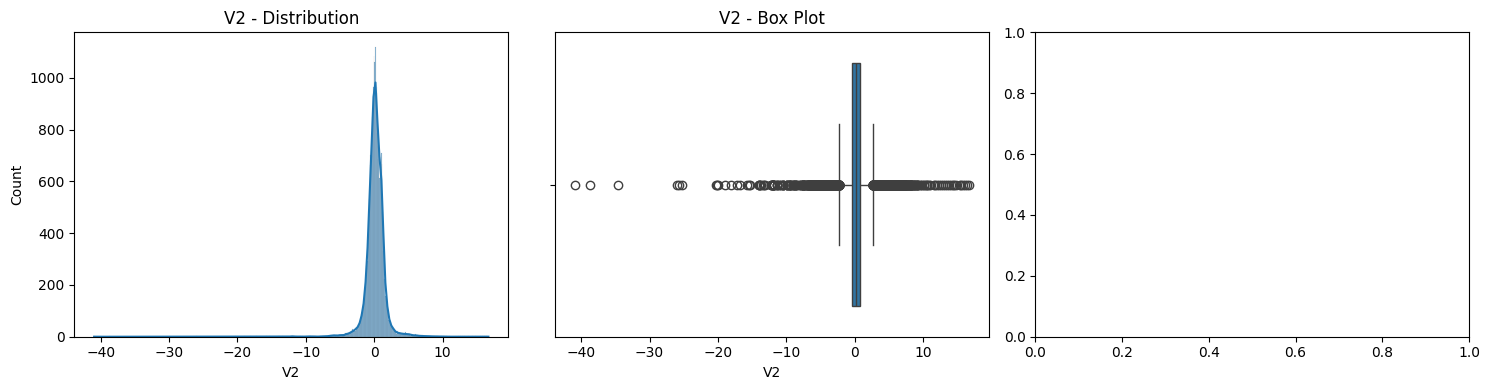

V2:
  Skewness: -2.866
  Kurtosis: 73.811


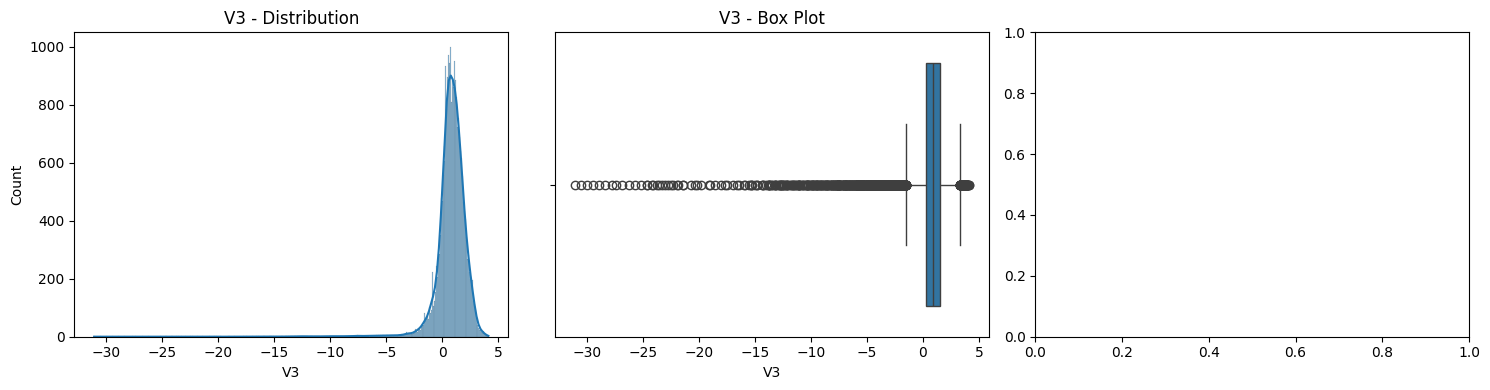

V3:
  Skewness: -6.857
  Kurtosis: 85.121


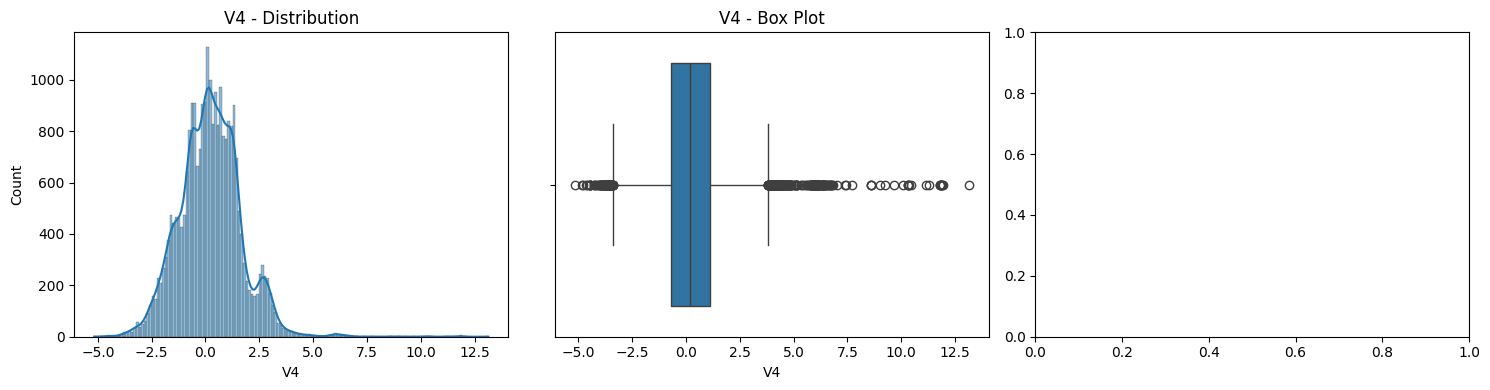

V4:
  Skewness: 0.592
  Kurtosis: 3.207


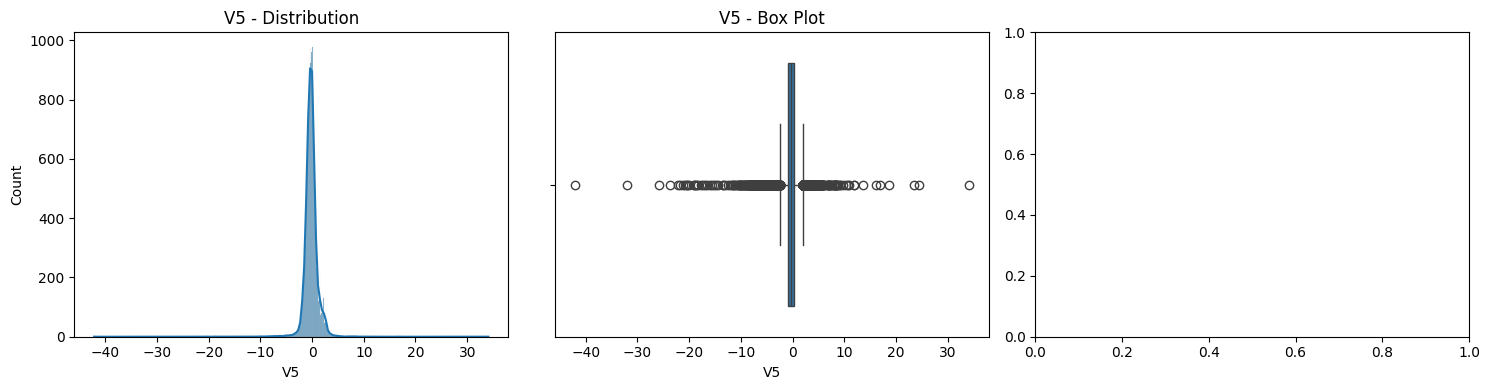

V5:
  Skewness: -2.605
  Kurtosis: 94.399


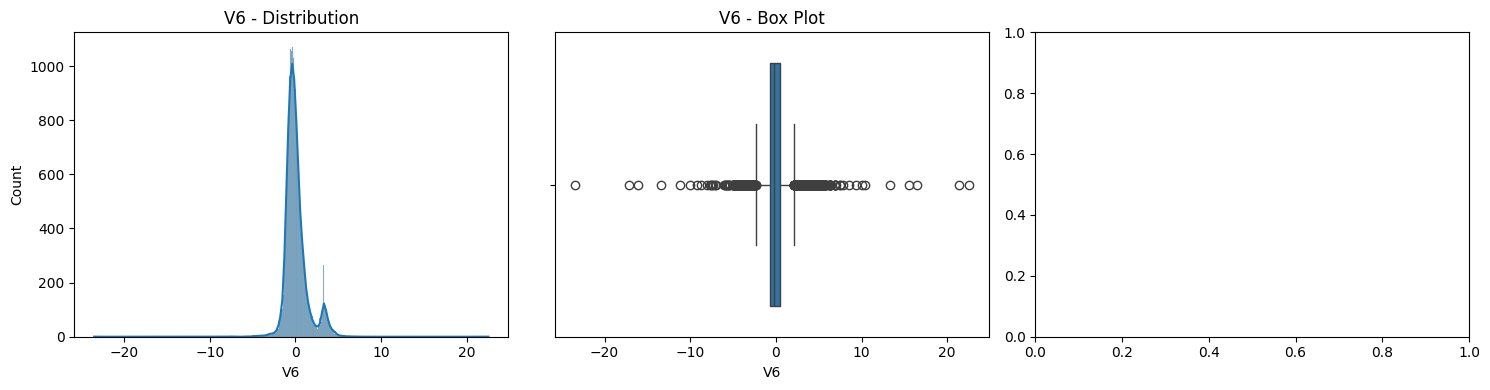

V6:
  Skewness: 1.193
  Kurtosis: 17.526


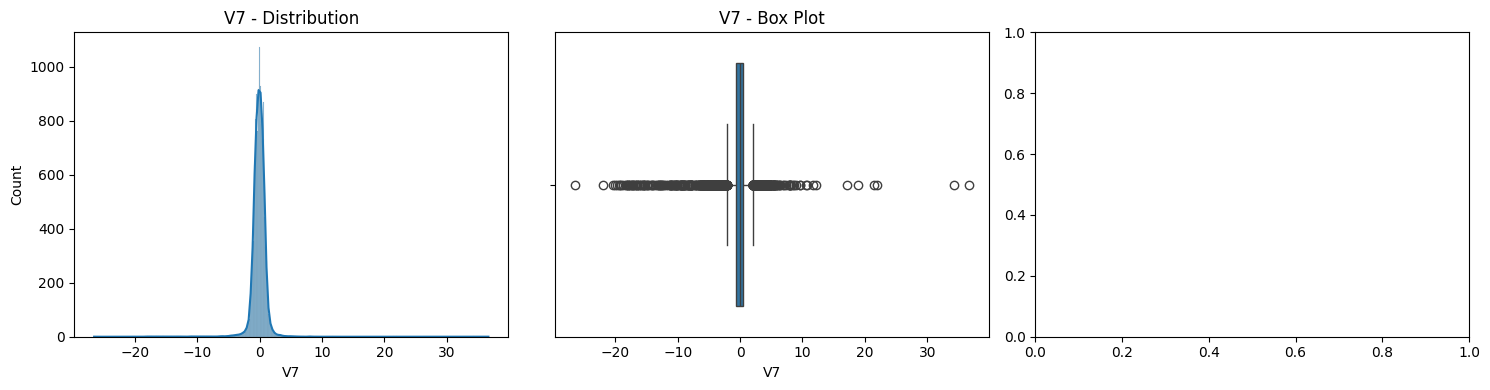

V7:
  Skewness: -2.572
  Kurtosis: 110.854


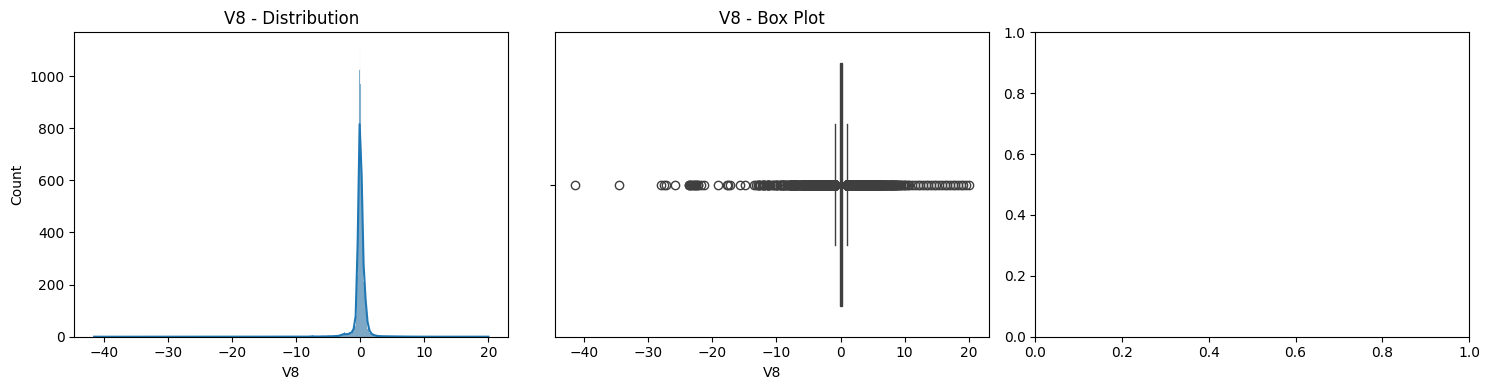

V8:
  Skewness: -5.653
  Kurtosis: 160.046


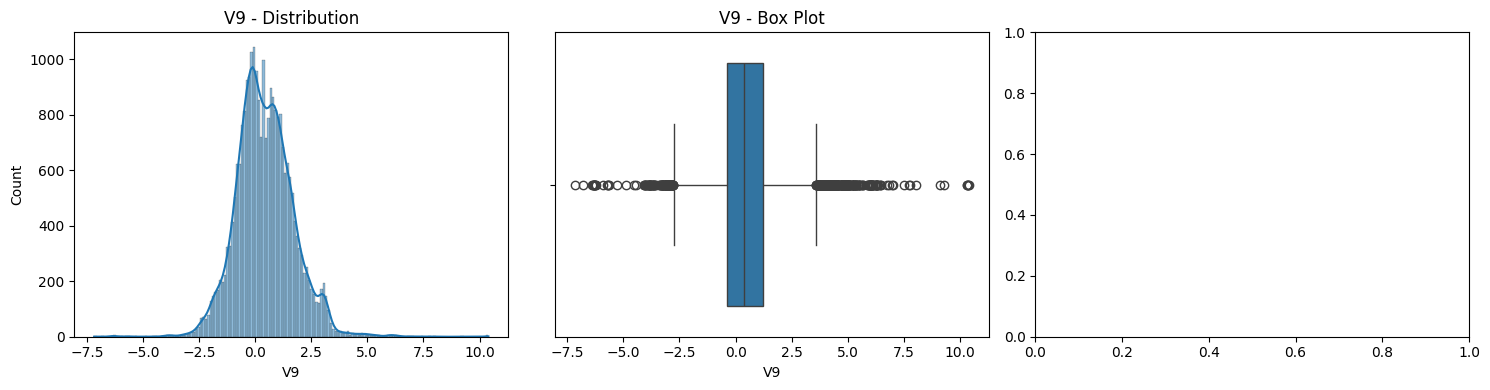

V9:
  Skewness: 0.423
  Kurtosis: 2.282


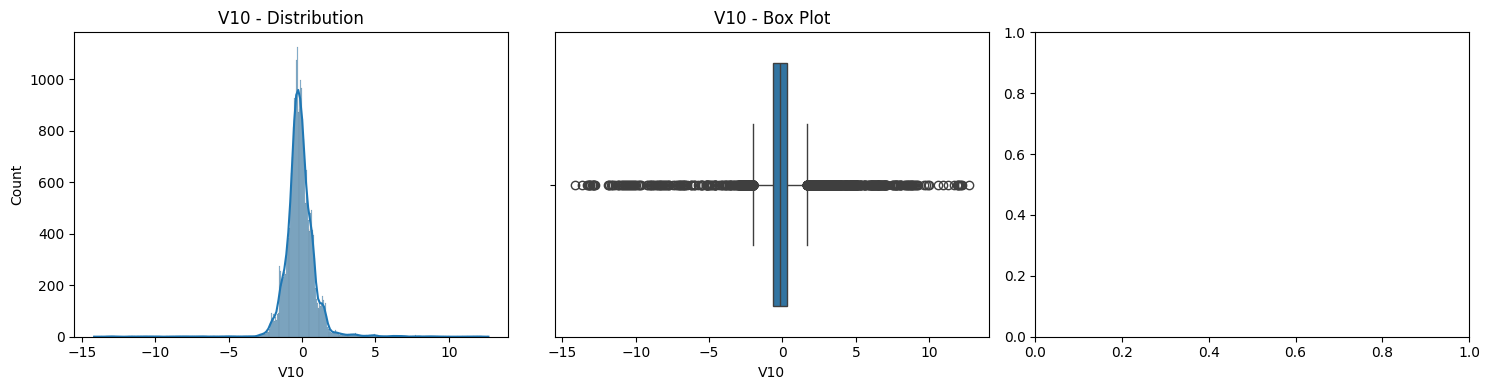

V10:
  Skewness: -0.232
  Kurtosis: 29.868


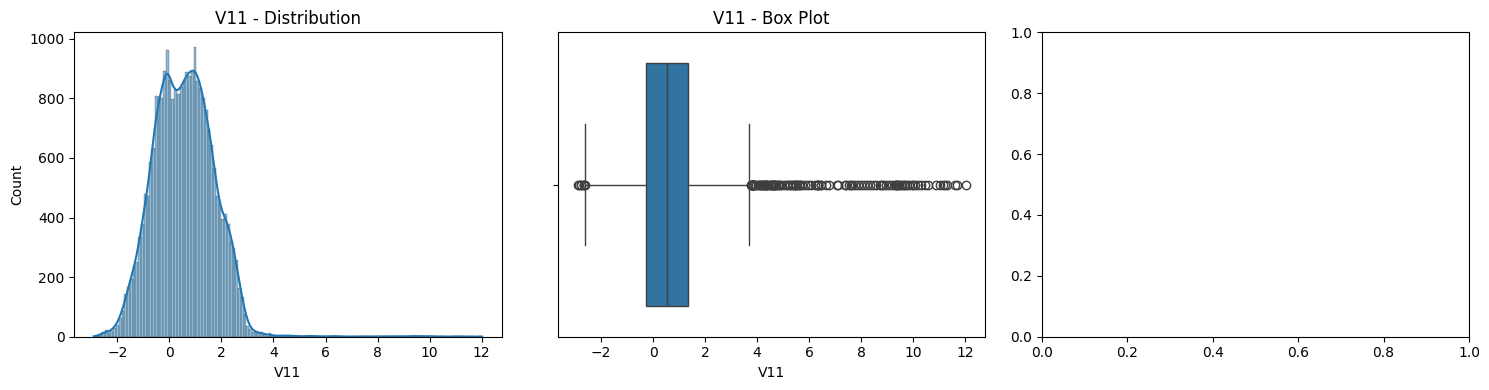

V11:
  Skewness: 0.934
  Kurtosis: 6.081


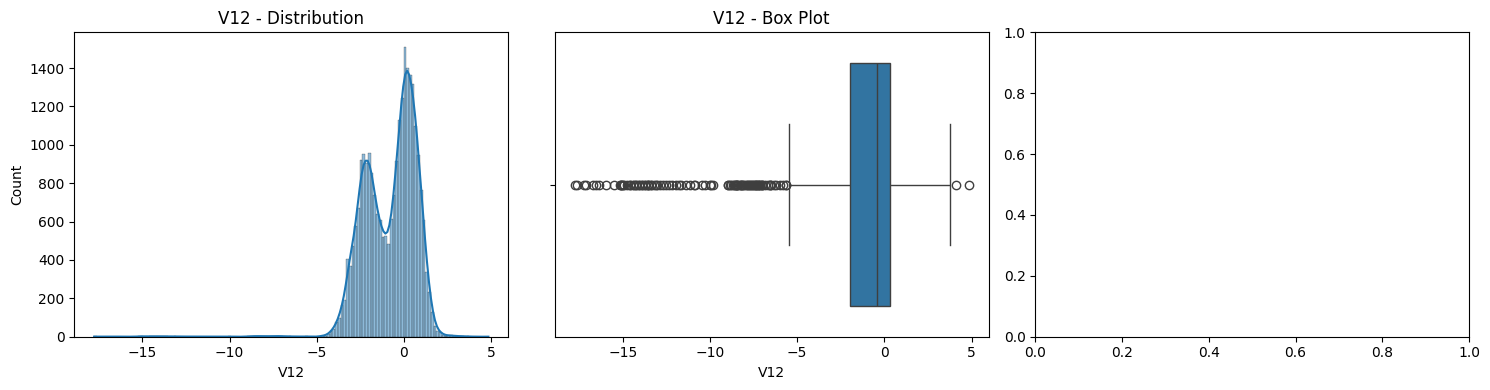

V12:
  Skewness: -1.661
  Kurtosis: 11.307


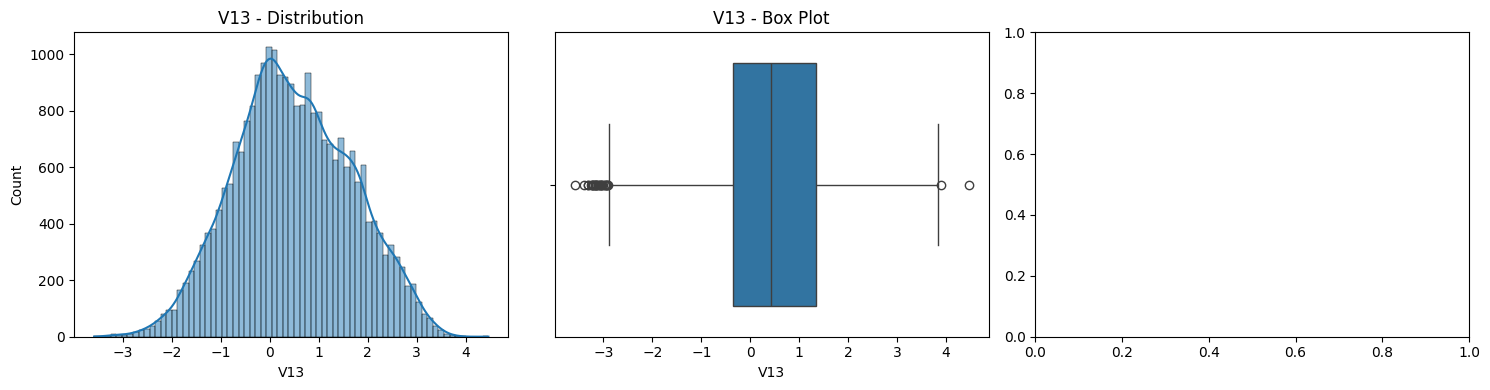

V13:
  Skewness: 0.054
  Kurtosis: -0.418


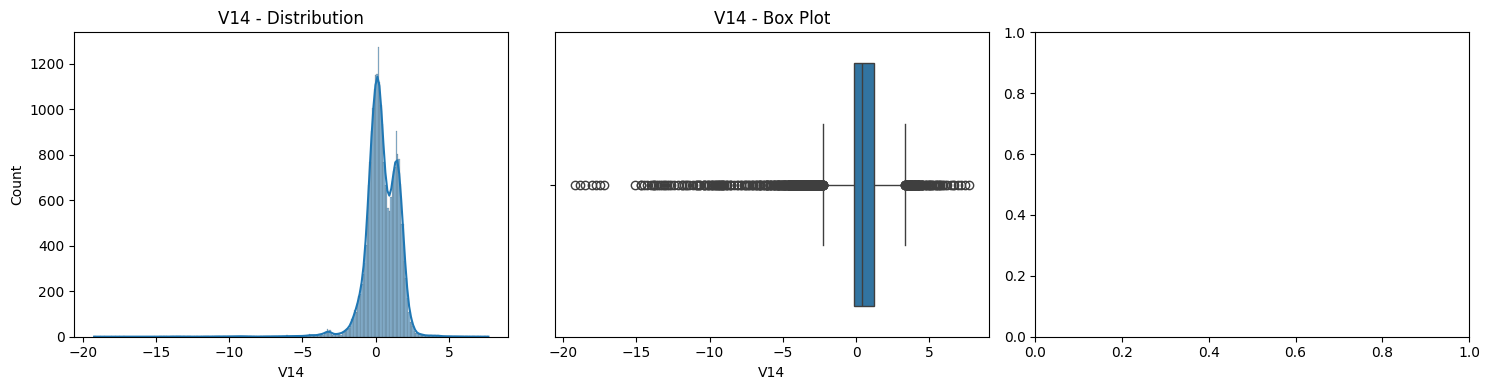

V14:
  Skewness: -3.420
  Kurtosis: 34.789


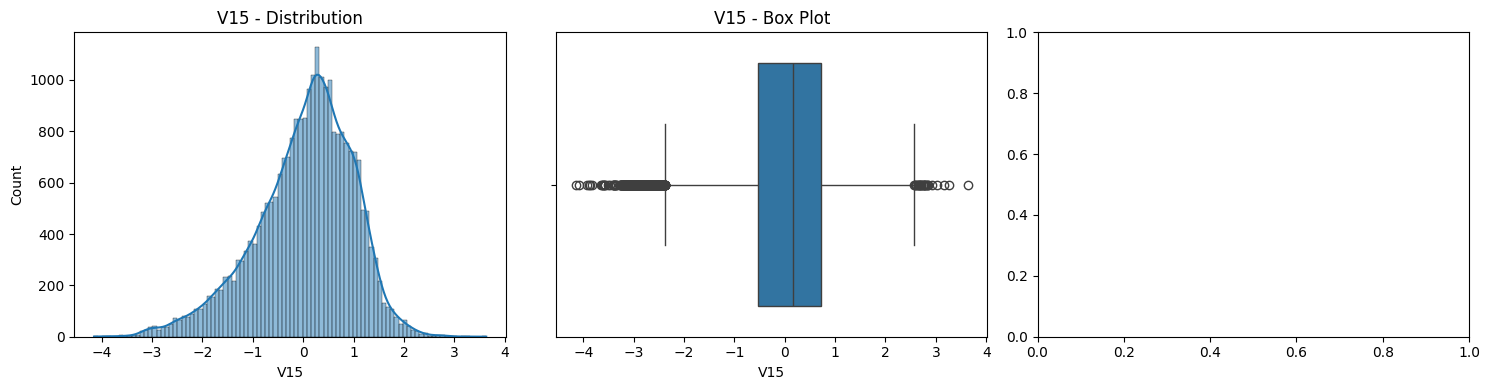

V15:
  Skewness: -0.615
  Kurtosis: 0.446


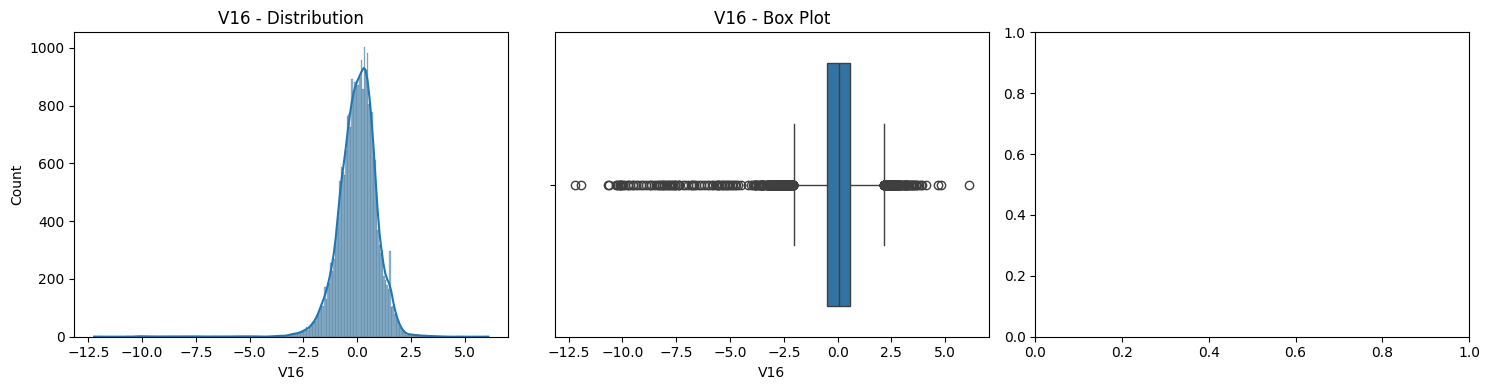

V16:
  Skewness: -2.134
  Kurtosis: 18.613


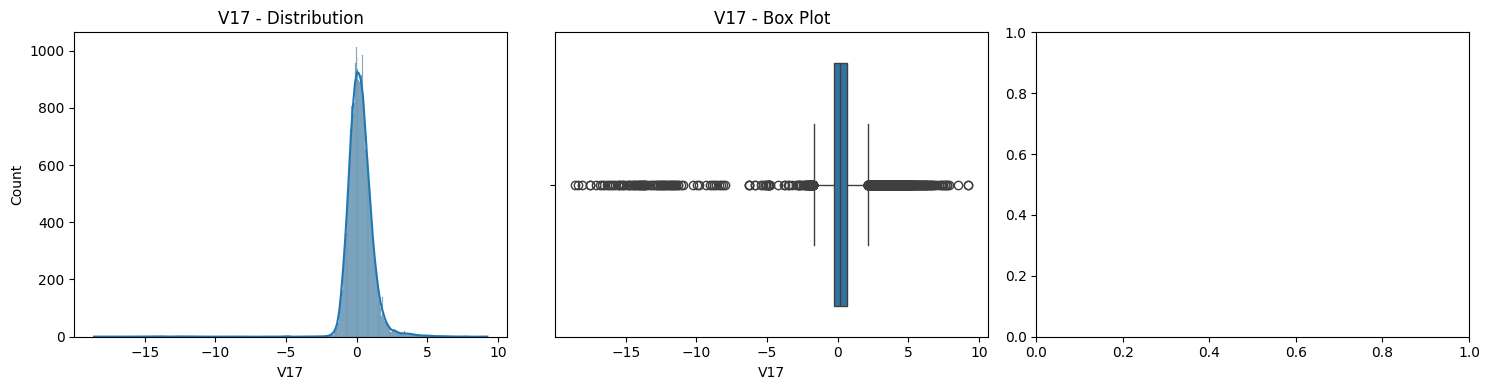

V17:
  Skewness: -4.739
  Kurtosis: 70.860


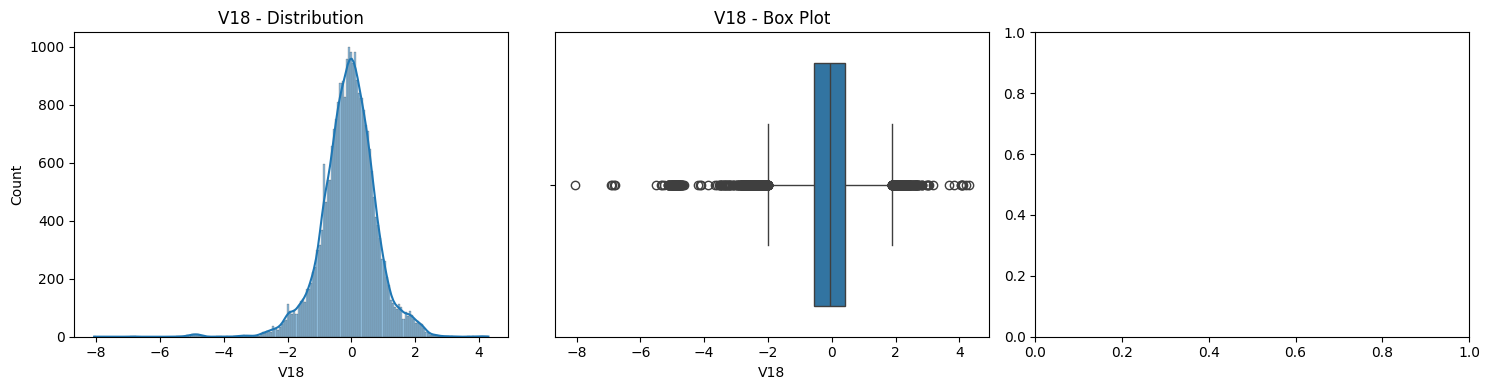

V18:
  Skewness: -0.582
  Kurtosis: 3.782


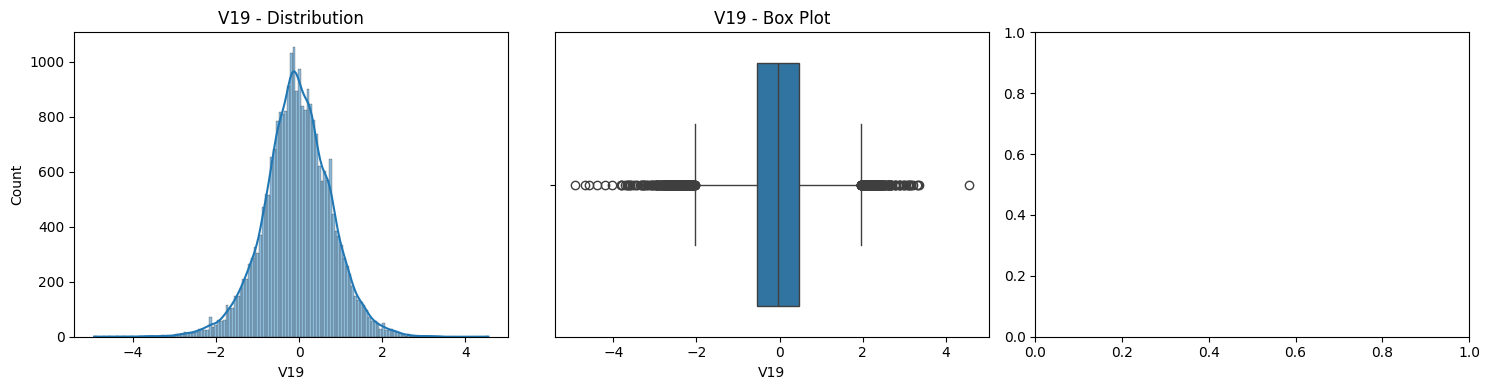

V19:
  Skewness: -0.148
  Kurtosis: 0.975


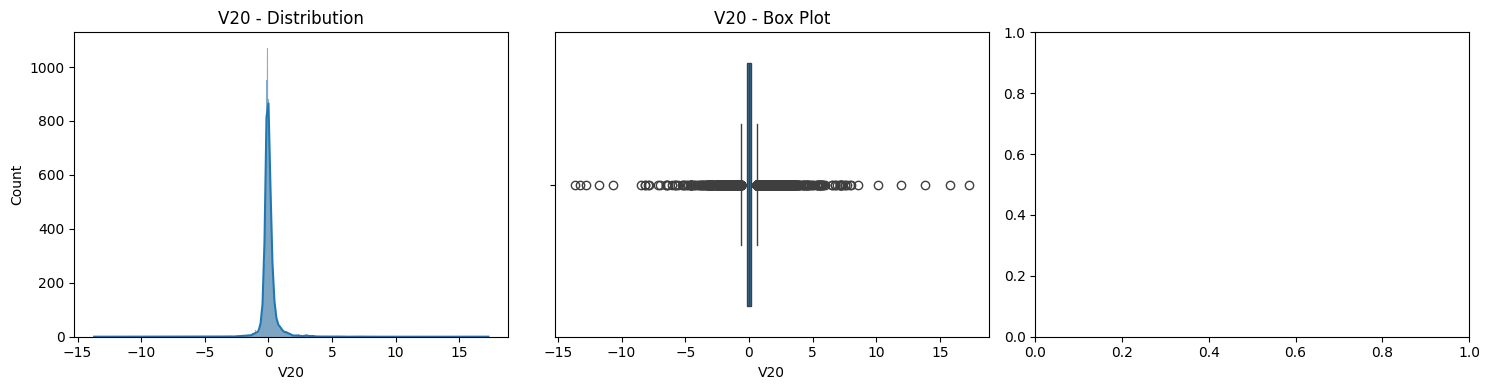

V20:
  Skewness: 1.787
  Kurtosis: 97.718


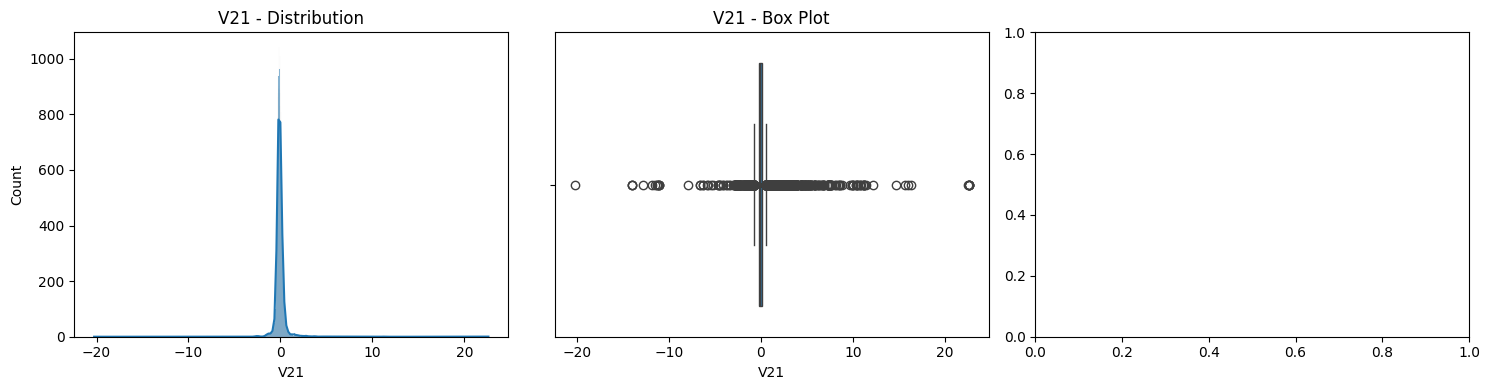

V21:
  Skewness: 7.243
  Kurtosis: 231.980


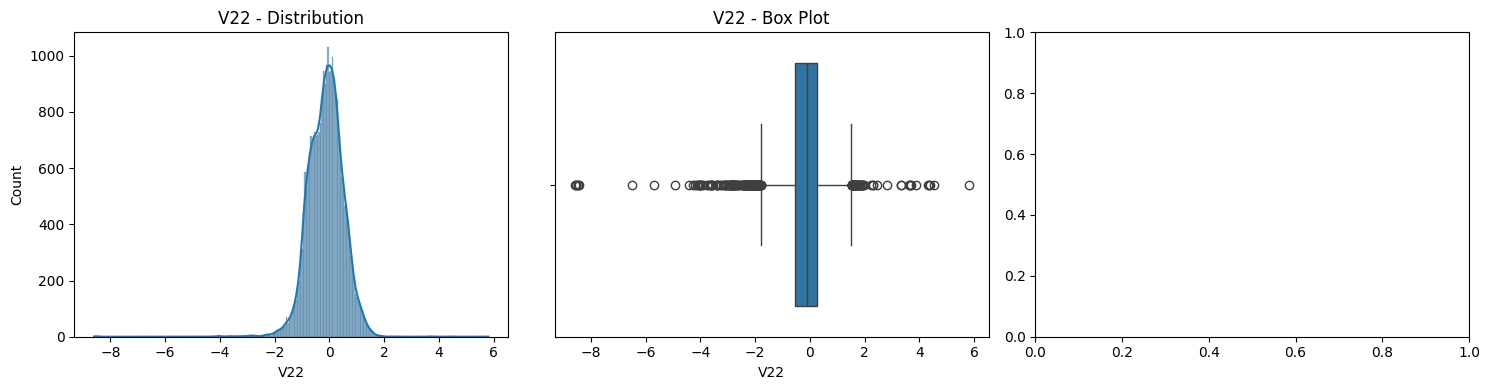

V22:
  Skewness: -0.784
  Kurtosis: 9.412


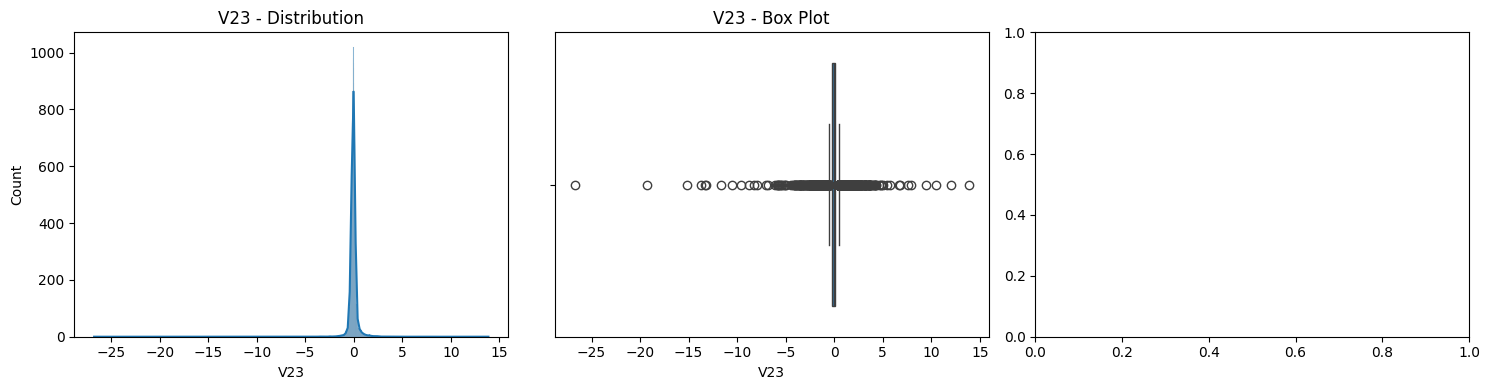

V23:
  Skewness: -8.412
  Kurtosis: 444.473


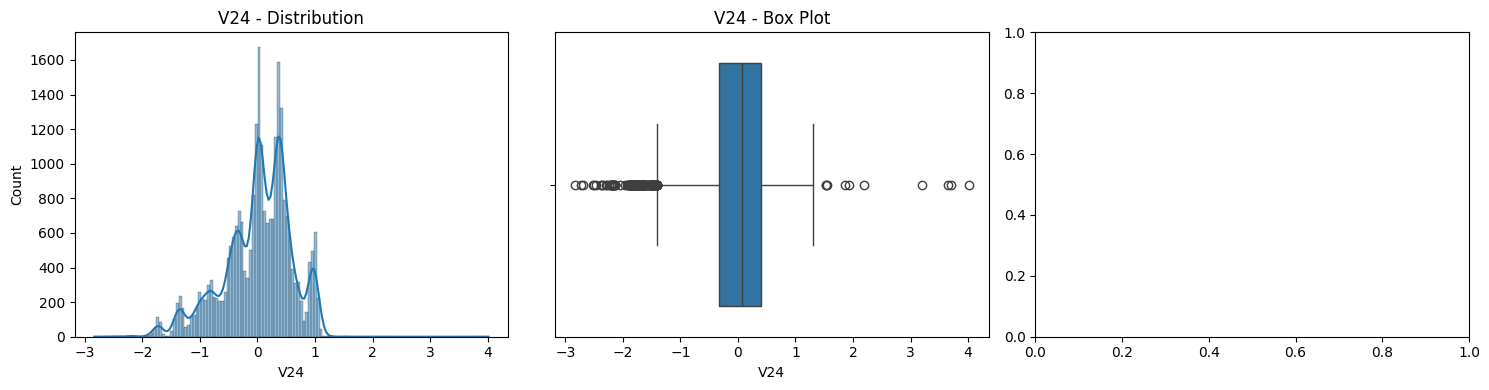

V24:
  Skewness: -0.642
  Kurtosis: 0.653


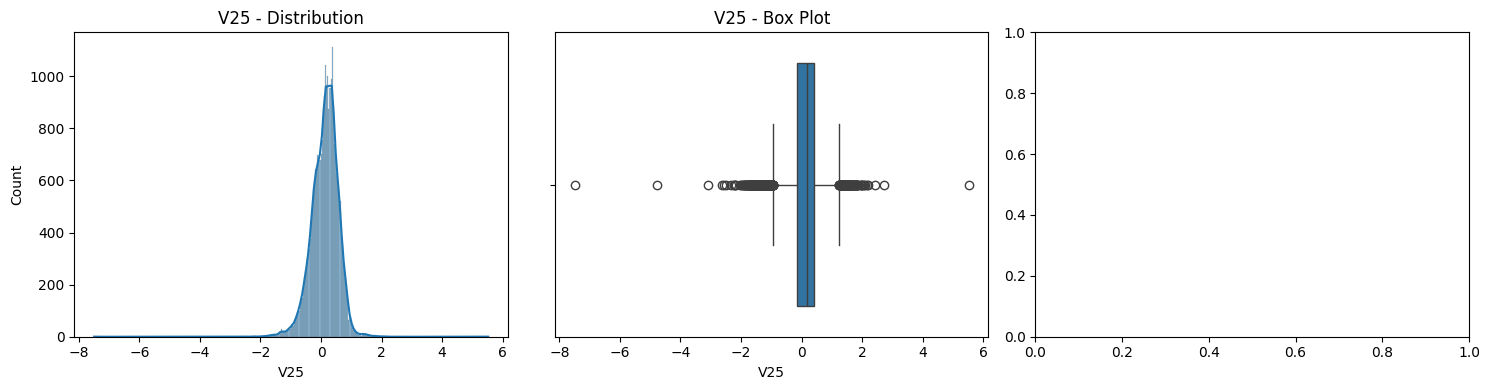

V25:
  Skewness: -0.671
  Kurtosis: 6.621


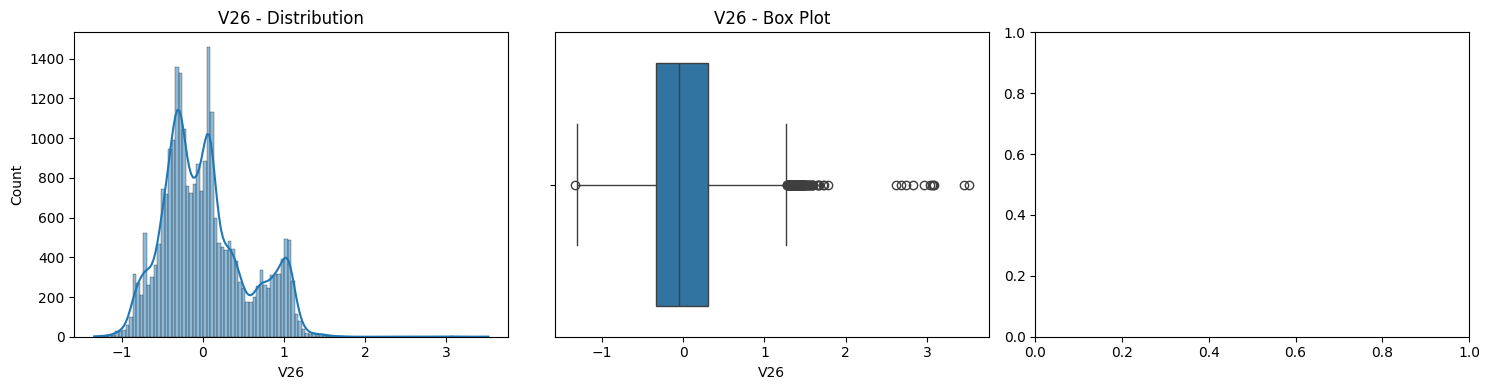

V26:
  Skewness: 0.643
  Kurtosis: 0.104


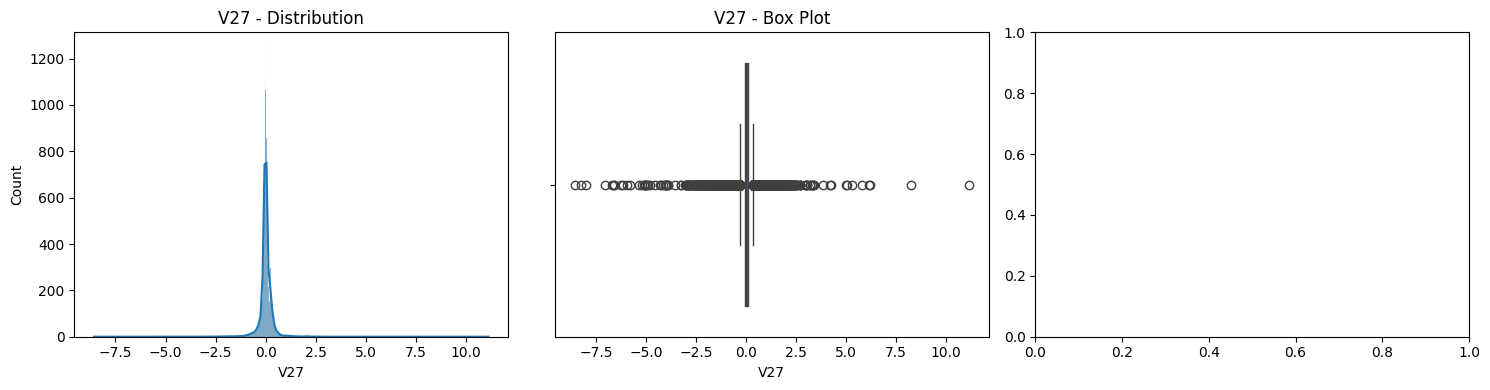

V27:
  Skewness: -1.717
  Kurtosis: 108.311


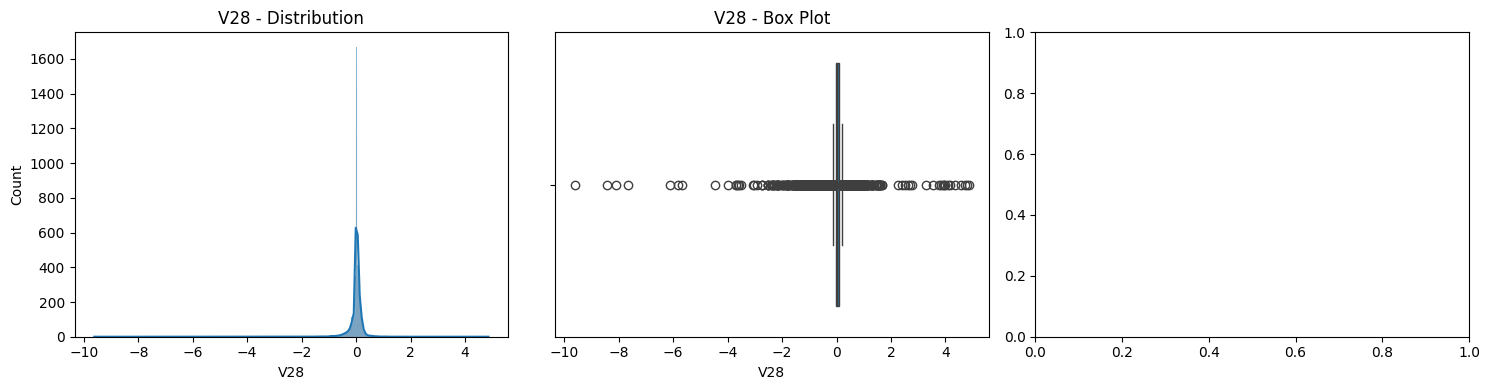

V28:
  Skewness: -5.552
  Kurtosis: 204.521


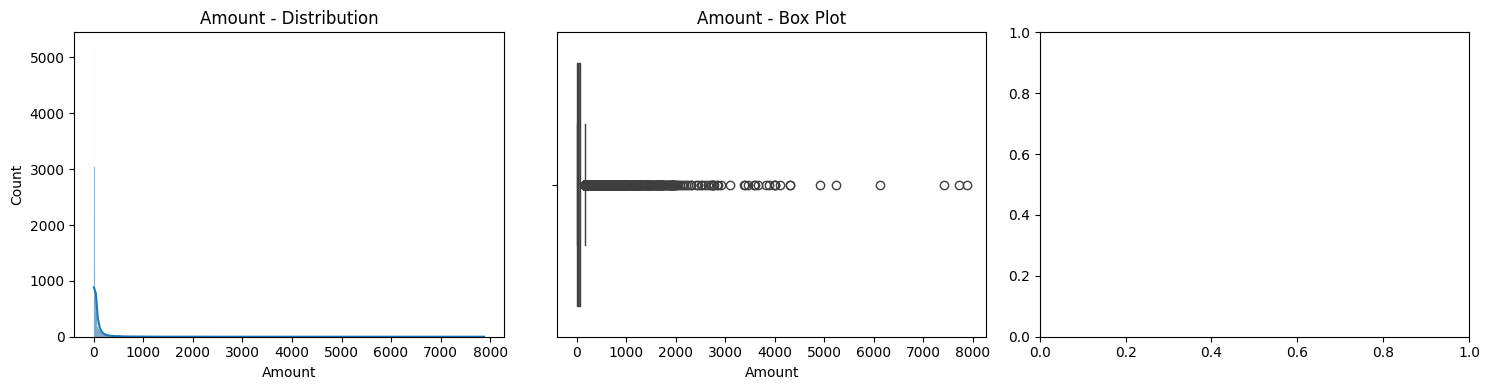

Amount:
  Skewness: 12.718
  Kurtosis: 283.026


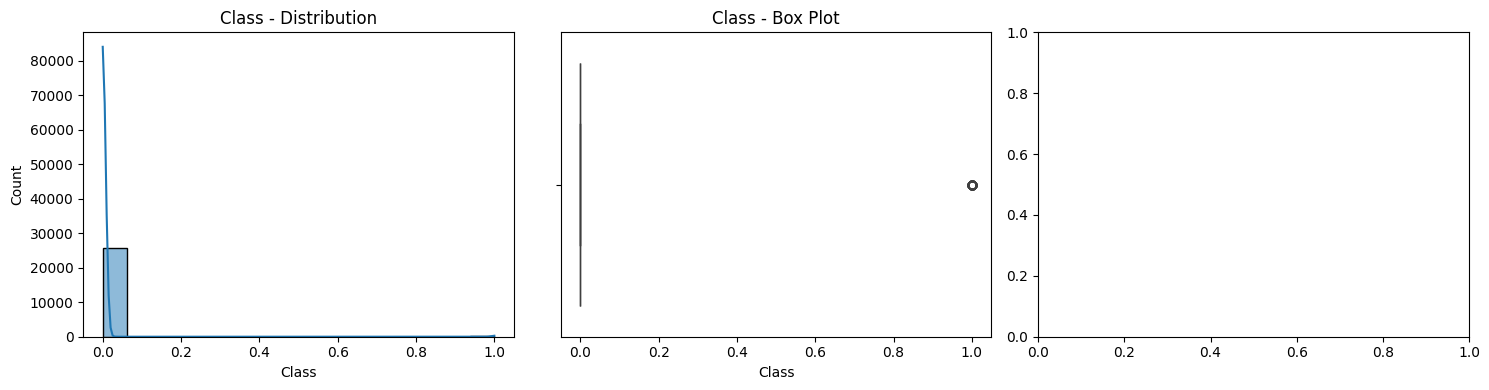

Class:
  Skewness: 17.048
  Kurtosis: 288.662


In [ ]:
for col in df.columns:
  fig, axes = plt.subplots(1, 3, figsize=(15, 4))

  # Histogram with KDE
  sns.histplot(df[col], kde=True, ax=axes[0])
  axes[0].set_title(f'{col} - Distribution')

  # Box plot for outliers
  sns.boxplot(x=df[col], ax=axes[1])
  axes[1].set_title(f'{col} - Box Plot')
  plt.tight_layout()
  plt.show()

  # Statistics
  print(f"{col}:")
  print(f"  Skewness: {df[col].skew():.3f}")
  print(f"  Kurtosis: {df[col].kurtosis():.3f}")

# Data Scaling

In [ ]:
scaler = StandardScaler()
df["Time"] = scaler.fit_transform(df[["Time"]])
df["Amount"] = scaler.fit_transform(df[["Amount"]])
print(df.head())

       Time        V1        V2        V3        V4        V5        V6  \
0 -1.662663 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388   
1 -1.662663  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361   
2 -1.662577 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
3 -1.662577 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4 -1.662491 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921   

         V7        V8        V9  ...       V21       V22       V23       V24  \
0  0.239599  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928   
1 -0.078803  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846   
2  0.791461  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281   
3  0.237609  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575   
4  0.592941 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267   

        V25       V26       V27       V28    Amount  Class  
0  0.12

# Different Model Choosing

In [ ]:
# Train, test, val split

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Original Class Distribution")
print(y_train.value_counts())
print(y_val.value_counts())
print(y_test.value_counts())


# Model 1: baseline

baseline_model = LogisticRegression(max_iter=1000,random_state=42)
baseline_model.fit(X_train, y_train)
baseline_val_pred = baseline_model.predict(X_val)
baseline_test_pred = baseline_model.predict(X_test)

# Model 2: Undersampling

train_df = pd.concat([X_train, y_train], axis=1)
legit_train = train_df[train_df["Class"] == 0]
fraud_train = train_df[train_df["Class"] == 1]

legit_under = resample(legit_train,replace=False,n_samples=len(fraud_train),random_state=42)
under_train = pd.concat([legit_under, fraud_train])

X_train_under = under_train.drop(columns=["Class"])
y_train_under = under_train["Class"]

print("Undersampled Distribution")
print(y_train_under.value_counts())

undersample_model = LogisticRegression(max_iter=1000,random_state=42)
undersample_model.fit(X_train_under, y_train_under)

under_val_pred = undersample_model.predict(X_val)
under_test_pred = undersample_model.predict(X_test)

# Model 3: SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

print("SMOTE Distribution")
print(y_train_smote.value_counts())

smote_model = LogisticRegression(max_iter=1000,random_state=42)

smote_model.fit(X_train_smote, y_train_smote)

smote_val_pred = smote_model.predict(X_val)
smote_test_pred = smote_model.predict(X_test)


# Results

models = [
    ("Baseline", baseline_val_pred, baseline_test_pred),
    ("Undersampled", under_val_pred, under_test_pred),
    ("SMOTE", smote_val_pred, smote_test_pred)
]

for name, val_pred, test_pred in models:

    print(f"Model Name: {name}")
    print(f"Validation Accuracy: {accuracy_score(y_val, val_pred)}")
    print("Validation Report")
    print(classification_report(y_val, val_pred))

    print(f"Test Accuracy: {accuracy_score(y_test, test_pred)}")
    print("Test Report")
    print(classification_report(y_test, test_pred))

Original Class Distribution
Class
0    170589
1       295
Name: count, dtype: int64
Class
0    56863
1       98
Name: count, dtype: int64
Class
0    56863
1       99
Name: count, dtype: int64


KeyboardInterrupt: 

# Visuals

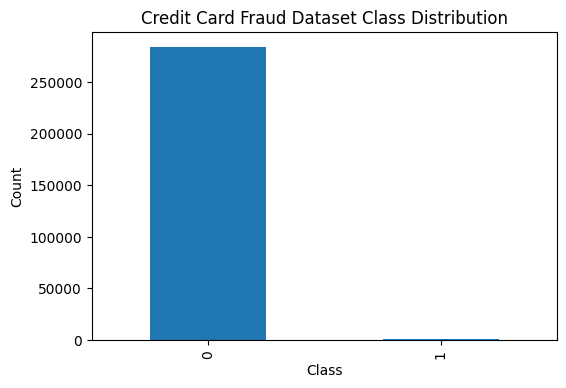

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


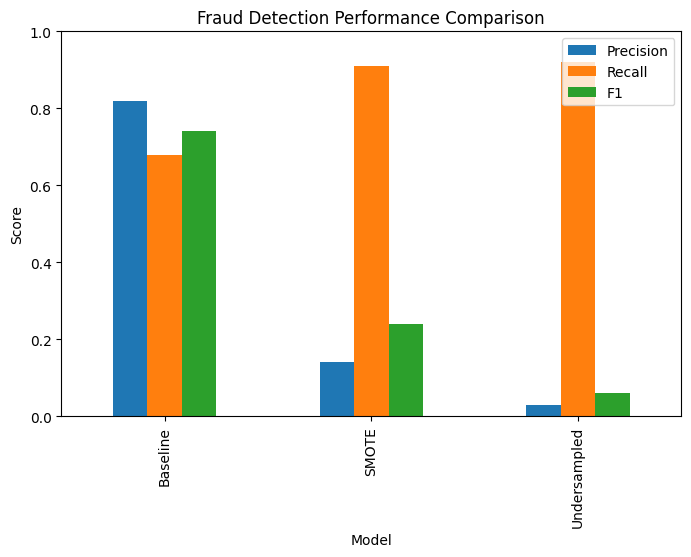

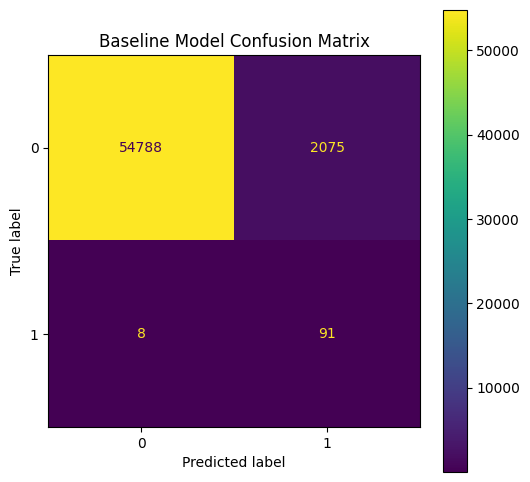

NameError: name 'model_smote' is not defined

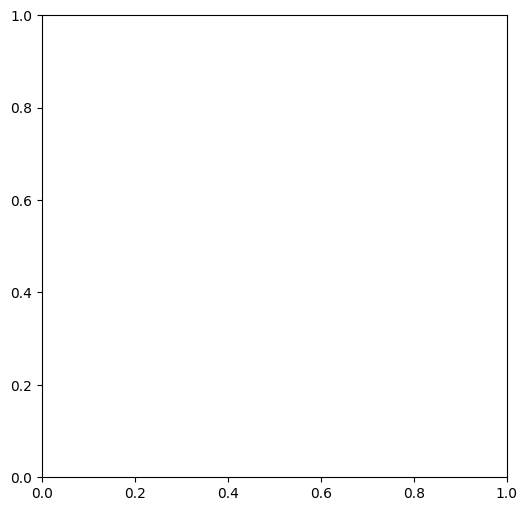

In [ ]:
plt.figure(figsize=(6,4))
df["Class"].value_counts().plot(kind="bar")
plt.title("Credit Card Fraud Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(df["Class"].value_counts(normalize=True)*100)


results = pd.DataFrame({
    "Model":["Baseline","SMOTE","Undersampled"],
    "Precision":[0.82,0.14,0.03],
    "Recall":[0.68,0.91,0.92],
    "F1":[0.74,0.24,0.06]
})

results.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Fraud Detection Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="best")
plt.show()


from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    ax=ax
)

plt.title("Baseline Model Confusion Matrix")
plt.show()

fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay.from_estimator(
    model_smote,
    X_test,
    y_test,
    ax=ax
)

plt.title("SMOTE Model Confusion Matrix")
plt.show()

from sklearn.metrics import roc_curve, roc_auc_score

probs = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr,
         label=f"AUC = {roc_auc_score(y_test, probs):.3f}")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()